<a href="https://colab.research.google.com/github/Winskiii/Road-Safety/blob/main/EDA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pairplot sangat berguna untuk melihat hubungan antara beberapa pasang fitur sekaligus dan melihat distribusinya berdasarkan variabel target. Ini bisa memberikan wawasan yang cepat tentang variabel mana yang paling potensial.

Grafik ini akan menampilkan scatter plot untuk setiap pasangan fitur dan histogram/KDE plot untuk distribusi setiap fitur tunggal.
Anda bisa melihat apakah ada pengelompokan (cluster) yang jelas antara tingkat keparahan yang berbeda untuk pasangan fitur tertentu. Misalnya, apakah ada kombinasi antara age_of_casualty dan casualty_imd_decile yang cenderung menghasilkan tingkat keparahan tertentu.


Membuat Pairplot... Ini mungkin memakan waktu beberapa saat.


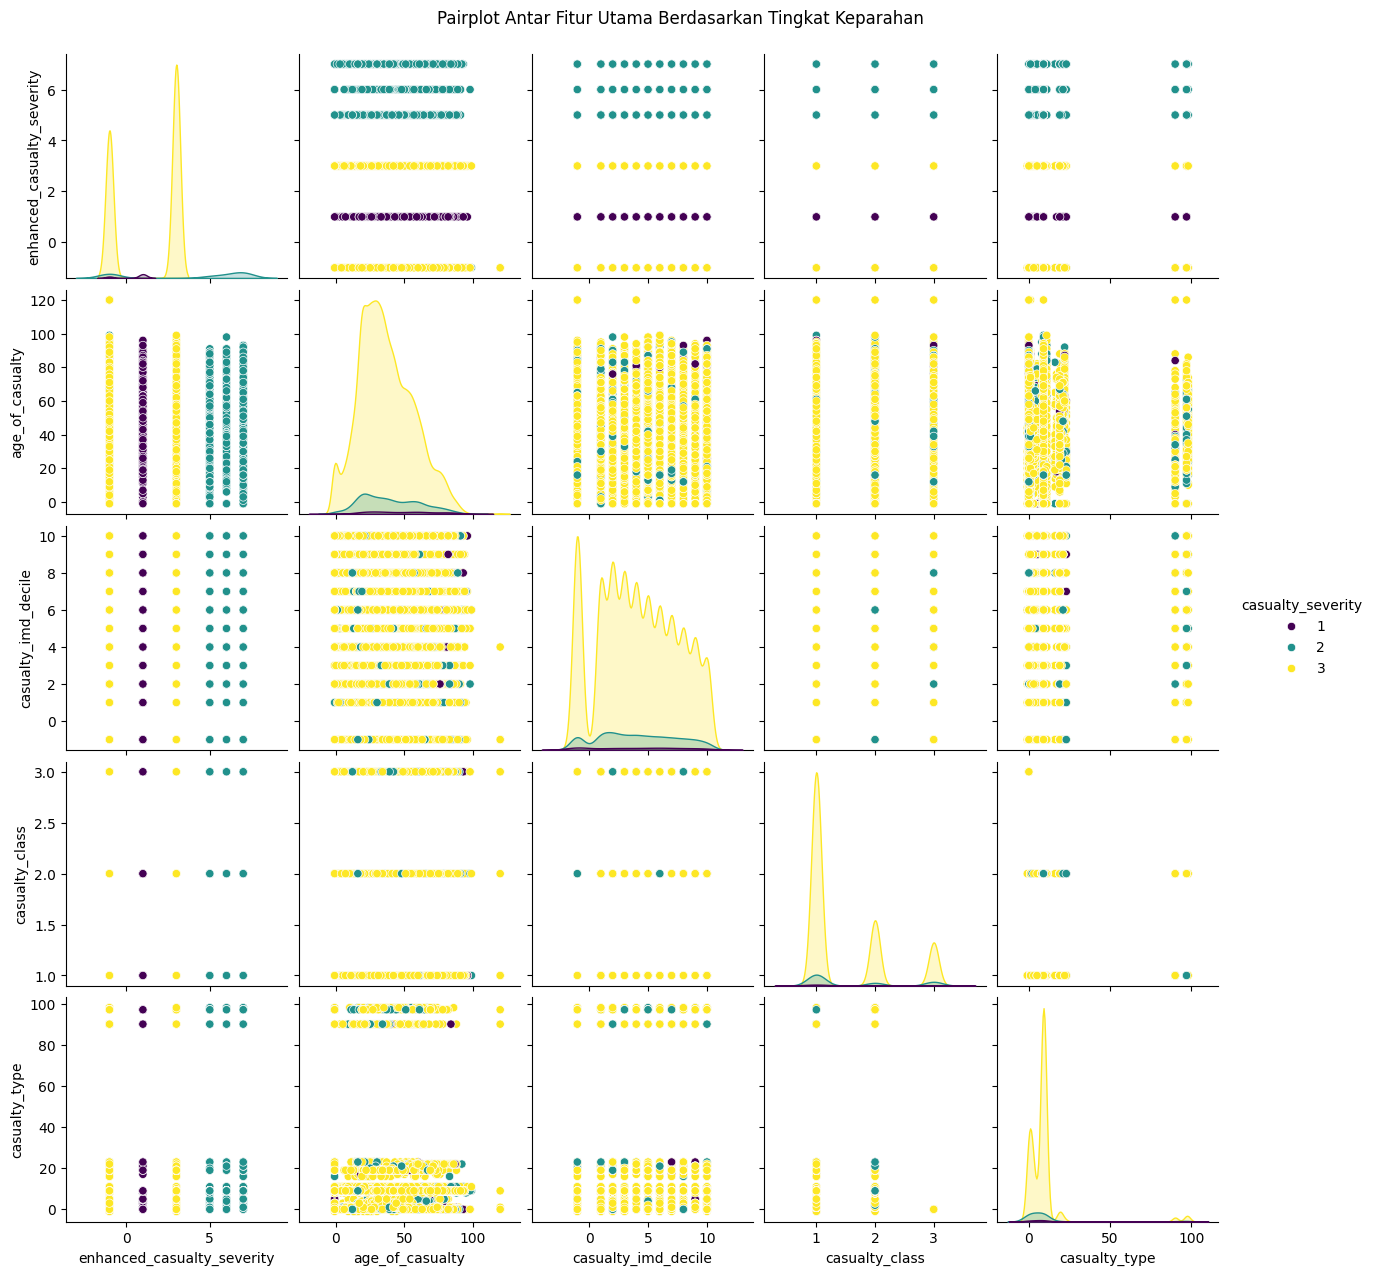

In [ ]:
# SEL BARU: EDA TAMBAHAN - PAIRPLOT UNTUK FITUR-FITUR UTAMA

import seaborn as sns
import matplotlib.pyplot as plt

# Memilih beberapa fitur numerik yang paling relevan untuk dianalisis
# Berdasarkan feature importance sebelumnya, kita bisa pilih beberapa fitur teratas
fitur_untuk_pairplot = [
    'casualty_severity',
    'enhanced_casualty_severity',
    'age_of_casualty',
    'casualty_imd_decile',
    'casualty_class',
    'casualty_type'
]

# Membuat pairplot
# hue='casualty_severity' akan mewarnai titik data berdasarkan tingkat keparahan
print("Membuat Pairplot... Ini mungkin memakan waktu beberapa saat.")
sns.pairplot(df[fitur_untuk_pairplot], hue='casualty_severity', palette='viridis', diag_kind='kde')
plt.suptitle('Pairplot Antar Fitur Utama Berdasarkan Tingkat Keparahan', y=1.02)
plt.show()

Setelah Anda mengetahui dari sel pertama bahwa data Anda tidak seimbang (kemungkinan besar, kasus 'Fatal' jauh lebih sedikit dari 'Ringan'), Imbalanced EDA menjadi sangat penting. Tujuannya bukan lagi melihat distribusi data secara keseluruhan, tetapi membandingkan distribusi fitur antara kelas mayoritas dan kelas minoritas.

Dengan cara ini, Anda bisa menemukan fitur-fitur yang memiliki pola sangat berbeda pada kasus kecelakaan fatal dibandingkan kasus ringan. Ini adalah petunjuk kuat mengenai fitur apa yang paling prediktif untuk kelas yang paling penting (dan paling jarang).

<ipython-input-12-1047626896>:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['casualty_severity'] == 1]['age_of_casualty'], label='Fatal (1)', shade=True)
<ipython-input-12-1047626896>:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['casualty_severity'] == 2]['age_of_casualty'], label='Serius (2)', shade=True)
<ipython-input-12-1047626896>:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['casualty_severity'] == 3]['age_of_casualty'], label='Ringan (3)', shade=True)


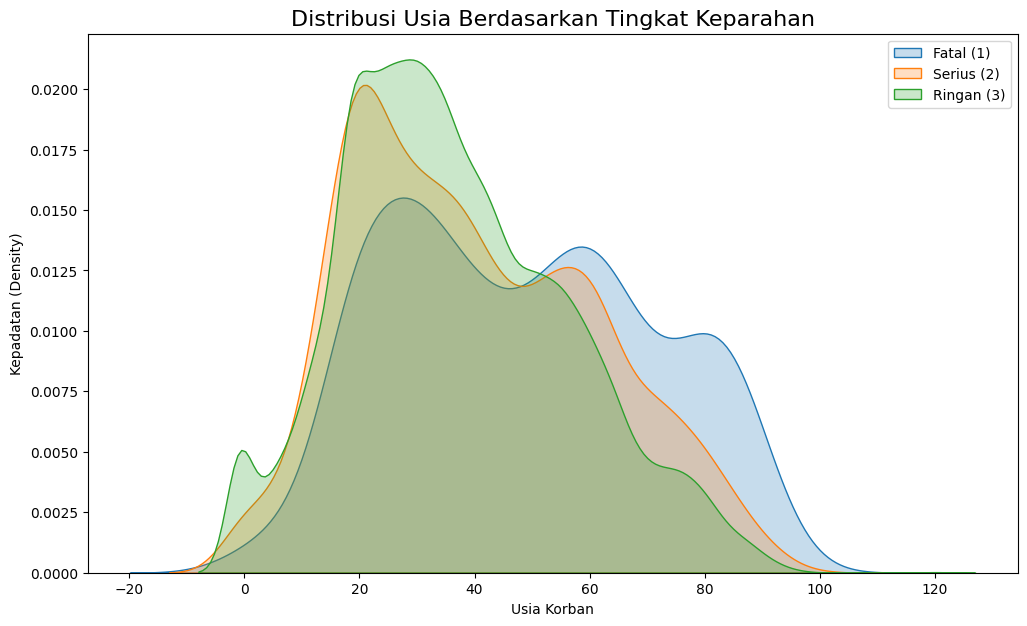

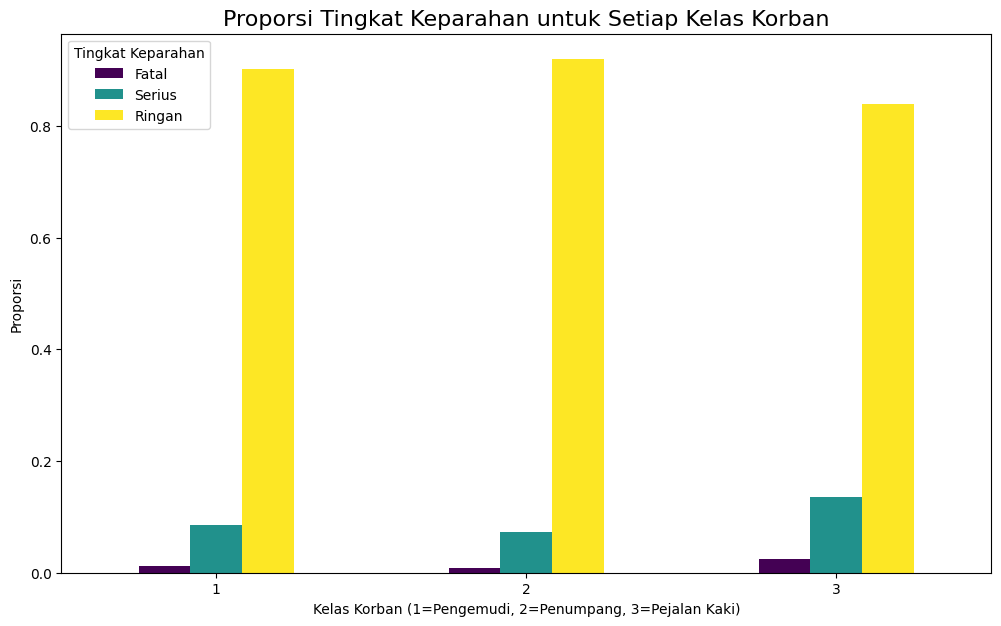

Proporsi Tingkat Keparahan untuk Setiap Kelas Korban:
casualty_severity         1         2         3
casualty_class                                 
1                  0.012800  0.084750  0.902449
2                  0.008978  0.072039  0.918983
3                  0.025067  0.136377  0.838556


In [ ]:
# SEL BARU: EDA UNTUK DATA TIDAK SEIMBANG

# Membandingkan distribusi fitur numerik (contoh: Usia)
plt.figure(figsize=(12, 7))
sns.kdeplot(df[df['casualty_severity'] == 1]['age_of_casualty'], label='Fatal (1)', shade=True)
sns.kdeplot(df[df['casualty_severity'] == 2]['age_of_casualty'], label='Serius (2)', shade=True)
sns.kdeplot(df[df['casualty_severity'] == 3]['age_of_casualty'], label='Ringan (3)', shade=True)
plt.title('Distribusi Usia Berdasarkan Tingkat Keparahan', fontsize=16)
plt.xlabel('Usia Korban')
plt.ylabel('Kepadatan (Density)')
plt.legend()
plt.show()

# Membandingkan distribusi fitur kategorikal (contoh: Kelas Korban)
# Gunakan normalize='index' untuk melihat proporsi/persentase, bukan jumlah absolut
crosstab_norm = pd.crosstab(df['casualty_class'], df['casualty_severity'], normalize='index')

crosstab_norm.plot(kind='bar', stacked=False, figsize=(12, 7), colormap='viridis')
plt.title('Proporsi Tingkat Keparahan untuk Setiap Kelas Korban', fontsize=16)
plt.xlabel('Kelas Korban (1=Pengemudi, 2=Penumpang, 3=Pejalan Kaki)')
plt.ylabel('Proporsi')
plt.xticks(rotation=0)
plt.legend(title='Tingkat Keparahan', labels=['Fatal', 'Serius', 'Ringan'])
plt.show()

print("Proporsi Tingkat Keparahan untuk Setiap Kelas Korban:")
print(crosstab_norm)

Pengecekan Encoder: Ordinal vs. Nominal (One-Hot)
Penjelasan:
Catatan "mengecek encode ordinal atau tidak" adalah inti dari best practice dalam pra-pemrosesan data. Dosen Anda mengingatkan bahwa tidak semua fitur kategorikal itu sama. Ada dua jenis utama:

Fitur Nominal: Kategori yang tidak memiliki tingkatan atau urutan yang jelas. Contoh: sex_of_casualty ('Pria', 'Wanita') atau casualty_type ('Mobil', 'Motor', 'Pejalan Kaki'). Menggunakan LabelEncoder di sini (yang mengubahnya menjadi 0, 1, 2) bisa menyesatkan model, seolah-olah 'Motor' (1) lebih "tinggi" dari 'Mobil' (0). Pendekatan yang lebih tepat adalah One-Hot Encoding, yang mengubah setiap kategori menjadi kolom baru dengan nilai 0 atau 1.

Fitur Ordinal: Kategori yang memiliki tingkatan atau urutan yang jelas. Contoh: age_band_of_casualty (karena rentang usia memiliki urutan dari muda ke tua) atau casualty_imd_decile (desil memiliki urutan 1 sampai 10). Untuk fitur seperti ini, penggunaan OrdinalEncoder atau LabelEncoder sudah tepat.

Dengan membedakan keduanya, Anda memberikan informasi yang lebih akurat kepada model Anda.

Kode Implementasi:
Kita akan menggunakan ColumnTransformer untuk menerapkan encoder yang berbeda pada jenis fitur yang berbeda secara efisien.

In [ ]:
# SEL BARU: PENERAPAN ENCODER ORDINAL DAN ONE-HOT

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd

# Kita mulai lagi dari DataFrame 'df' yang sudah bersih
X = df.drop('casualty_severity', axis=1)
y = df['casualty_severity']

# 1. Pisahkan fitur berdasarkan jenisnya
# Fitur yang memiliki urutan/tingkatan
ordinal_features = ['age_band_of_casualty', 'casualty_imd_decile']

# Fitur yang tidak memiliki urutan (nominal)
# collision_index kita anggap sebagai numerik biasa (identifier)
nominal_features = [
    'casualty_class', 'sex_of_casualty', 'pedestrian_location',
    'pedestrian_movement', 'car_passenger', 'bus_or_coach_passenger',
    'pedestrian_road_maintenance_worker', 'casualty_type', 'casualty_home_area_type'
]

# Fitur numerik yang tersisa
numerical_features = [col for col in X.columns if col not in ordinal_features and col not in nominal_features]

print(f"Fitur Ordinal: {ordinal_features}")
print(f"Fitur Nominal: {nominal_features}")
print(f"Fitur Numerik: {numerical_features}")

# 2. Buat pipeline preprocessing
# handle_unknown='ignore' pada OneHotEncoder berguna jika data uji nanti memiliki kategori yg tidak ada di data latih
preprocessor_encoder = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(), ordinal_features),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_features)
    ],
    remainder='passthrough' # Biarkan kolom numerik tidak tersentuh untuk sementara
)

# 3. Terapkan transformasi
X_encoded = preprocessor_encoder.fit_transform(X)

# Mengambil nama kolom baru setelah One-Hot Encoding
new_column_names = list(preprocessor_encoder.named_transformers_['onehot'].get_feature_names_out(nominal_features))
final_column_names = ordinal_features + new_column_names + numerical_features

# Konversi hasilnya kembali ke DataFrame untuk kemudahan inspeksi
X_encoded_df = pd.DataFrame(X_encoded, columns=final_column_names)

print("\nDimensi data setelah encoding yang benar:", X_encoded_df.shape)
print("Contoh data setelah encoding:")
X_encoded_df.head()

Fitur Ordinal: ['age_band_of_casualty', 'casualty_imd_decile']
Fitur Nominal: ['casualty_class', 'sex_of_casualty', 'pedestrian_location', 'pedestrian_movement', 'car_passenger', 'bus_or_coach_passenger', 'pedestrian_road_maintenance_worker', 'casualty_type', 'casualty_home_area_type']
Fitur Numerik: ['collision_index', 'vehicle_reference', 'casualty_reference', 'age_of_casualty', 'enhanced_casualty_severity']

Dimensi data setelah encoding yang benar: (46649, 2451)
Contoh data setelah encoding:


,age_band_of_casualty,casualty_imd_decile,casualty_class_1,casualty_class_2,casualty_class_3,sex_of_casualty_-1.0,sex_of_casualty_1.0,sex_of_casualty_2.0,sex_of_casualty_9.0,pedestrian_location_-1.0,...,casualty_type_98,casualty_home_area_type_-1.0,casualty_home_area_type_1.0,casualty_home_area_type_2.0,casualty_home_area_type_3.0,collision_index,vehicle_reference,casualty_reference,age_of_casualty,enhanced_casualty_severity
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,2024061466412,1.0,1.0,-1,7
1,7.0,7.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,2024010509007,1.0,1.0,41,-1
2,3.0,4.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,2024031447234,2.0,1.0,14,3
3,2.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,2024201484457,1.0,1.0,9,3
4,7.0,2.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,2024010494553,1.0,2.0,36,-1


StandardScaler: Mengubah data sehingga memiliki rata-rata 0 dan standar deviasi 1. Baik untuk data yang distribusinya mendekati normal.
MinMaxScaler: Mengubah data ke dalam rentang tertentu, biasanya [0, 1].
RobustScaler: Sangat baik jika data Anda memiliki banyak pencilan (outliers), seperti yang Anda temukan di EDA sebelumnya. Scaler ini menggunakan median dan rentang interkuartil (IQR) sehingga tidak terpengaruh oleh nilai ekstrem.

In [ ]:
# SEL BARU: MEMBANDINGKAN EFEK DARI SCALER YANG BERBEDA

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
import pandas as pd

# Kita gunakan lagi pemisahan fitur dari sel sebelumnya
# Ordinal & Nominal features sudah didefinisikan di sel sebelumnya

# Fitur yang memiliki urutan/tingkatan
ordinal_features = ['age_band_of_casualty', 'casualty_imd_decile']

# Fitur yang tidak memiliki urutan (nominal)
# collision_index kita anggap sebagai numerik biasa (identifier)
nominal_features = [
    'casualty_class', 'sex_of_casualty', 'pedestrian_location',
    'pedestrian_movement', 'car_passenger', 'bus_or_coach_passenger',
    'pedestrian_road_maintenance_worker', 'casualty_type', 'casualty_home_area_type'
]

# Fitur numerik yang tersisa, excluding identifiers or potentially non-numeric columns
numerical_features = [col for col in X.columns if col not in ordinal_features and col not in nominal_features and col not in ['collision_index', 'vehicle_reference', 'casualty_reference', 'enhanced_casualty_severity']]


print(f"Fitur Ordinal: {ordinal_features}")
print(f"Fitur Nominal: {nominal_features}")
print(f"Fitur Numerik: {numerical_features}")


# List scaler yang akan diuji
scalers_to_scan = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler() # Pilihan bagus karena ada outlier
}

# Drop identifier columns from X before passing to the pipeline
X_processed = X.drop(['collision_index', 'vehicle_reference', 'casualty_reference', 'enhanced_casualty_severity'], axis=1)


# Loop untuk menguji setiap scaler
for scaler_name, scaler_obj in scalers_to_scan.items():

    # Buat pipeline lengkap: encoding untuk kategori, scaling untuk numerik
    # Ensure only actual numerical features are scaled
    preprocessor_full = ColumnTransformer(
        transformers=[
            ('num', scaler_obj, numerical_features), # Scale only the identified numerical features
            ('ord', OrdinalEncoder(), ordinal_features),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_features)
        ],
        remainder='passthrough' # Keep other columns (like identifiers) as they are
    )


    # Gabungkan preprocessing with model in one pipeline
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor_full),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42)) # Simple model for testing
    ])

    # Evaluate with cross-validation using the processed data
    scores = cross_val_score(model_pipeline, X_processed, y, cv=5, scoring='accuracy')

    print(f"--- Hasil untuk {scaler_name} ---")
    print(f"Rata-rata Akurasi: {scores.mean():.4f}")
    print(f"Standar Deviasi Akurasi: {scores.std():.4f}\n")

Fitur Ordinal: ['age_band_of_casualty', 'casualty_imd_decile']
Fitur Nominal: ['casualty_class', 'sex_of_casualty', 'pedestrian_location', 'pedestrian_movement', 'car_passenger', 'bus_or_coach_passenger', 'pedestrian_road_maintenance_worker', 'casualty_type', 'casualty_home_area_type']
Fitur Numerik: ['age_of_casualty']
--- Hasil untuk StandardScaler ---
Rata-rata Akurasi: 0.8965
Standar Deviasi Akurasi: 0.0000

